# **Proyecto final curso Data Science**

Predicción de resultados de próximos partidos internacionales de futbol

Alumna: Abril Nacif

Este proyecto tiene como objetivo construir un modelo de clasificación multiclase, que sea capaz de estimar si un partido termina en victoria de la Selección A, empate o victoria de la Selección B. Se utilizan únicamente datos conocidos antes de cada encuentro y el historial queda limitado al 31 de julio de 2026.

# Índice

1. [Abstracto](#sec-1)
2. [Formulación del problema](#sec-2)
3. [Importación de librerías y configuración inicial](#sec-3)
4. [Carga del dataset](#sec-4)
5. [Comprensión y control de calidad de los datos](#sec-5)
   - [5.1. Decisiones de limpieza](#sec-5-1)
6. [Análisis exploratorio de datos (EDA)](#sec-6)
   - [6.1. EDA univariado](#sec-6-1)
   - [6.2. EDA bivariado](#sec-6-2)
   - [6.3. Matriz de correlación](#sec-6-3)
7. [Ingeniería de variables](#sec-7)
8. [Separación temporal de entrenamiento y prueba](#sec-8)
9. [Análisis bivariado y ANOVA](#sec-9)
10. [Preprocesamiento](#sec-10)
11. [Modelos candidatos](#sec-11)
12. [Optimización con Grid Search y validación temporal](#sec-12)
13. [Evaluación final y selección del modelo](#sec-13)
    - [13.1. Comparación de modelos](#sec-13-1)
    - [13.2. Criterio y justificación de la elección](#sec-13-2)
    - [13.3. Interpretación](#sec-13-3)
14. [Aplicación a próximos partidos internacionales](#sec-14)
15. [Conclusiones generales](#sec-15)
16. [Limitaciones](#sec-16)
17. [Bibliografía](#sec-17)

<a id="sec-1"></a>
# 1. Abstracto

En este proyecto se busca analizar partidos internacionales de fútbol para predecir si el resultado será una victoria de la Selección A, un empate o una victoria de la Selección B. Se ha elegido este tema porque el fútbol es un deporte muy impredecible y nos interesa saber hasta qué punto se puede anticipar un resultado teniendo en cuenta el rendimiento reciente de las selecciones, sus resultados históricos y el contexto previo al encuentro.

Este análisis puede ser útil para cuerpos técnicos, analistas deportivos, medios de comunicación y aficionados que quieran contar con una estimación antes de un partido.

Para llevarlo a cabo, se crearán variables a partir de encuentros anteriores, se entrenarán y optimizarán 6 modelos de clasificación, y se los comparará mediante validación temporal. Luego, se seleccionará el modelo que obtuvo la mejor métrica, y dicho modelo será utilizado para predecir partidos internacionales disputados desde agosto de 2026 (post mundial).

<a id="sec-2"></a>
# 2. Formulación del problema

**Pregunta de negocio**: ¿podemos predecir el resultado de un partido internacional teniendo en cuenta el rendimiento reciente y el desempeño histórico de cada una de las selecciones?

**Tipo de aprendizaje**: este trabajo corresponde a un problema de aprendizaje supervisado ya que conocemos el resultado de cada partido histórico. Se trata de una clasificación multiclase porque la variable que se quiere predecir tiene 3 posibles resultados: gana la selección A, empate o gana la selección B.

**Objetivo**: entrenar y comparar 6 modelos de clasificación (Regresión logística, KNN, Árbol de decisión, Random Forest, ADABoost y XGBoost). Luego, buscamos optimizar sus hiperparámetros y seleccionar el modelo que tenga el mejor desempeño al momento de predecir partidos futuros.

<a id="sec-3"></a>
# 3. Importación de librerías y configuración inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
)
from sklearn.feature_selection import f_classif

# Importamos los 6 modelos que se utilizarán
from sklearn.linear_model import LogisticRegression # para el modelo de regresión logística
from sklearn.neighbors import KNeighborsClassifier # para el modelo KNN
from sklearn.tree import DecisionTreeClassifier # para el modelo árbol de decisión
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier # importa RandomForest y AdaBoost
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit # para optimizar los modelos y realizar validación temporal
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc
)

SEED = 42 # se define una semilla para obtener siempre los mismos resultados
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)

<a id="sec-4"></a>
# 4. Carga del dataset

In [4]:
DATA_URL = "https://raw.githubusercontent.com/abrilnacif2/Proyecto-Final-Data-Science/refs/heads/main/datos_oficial_partidos.csv"  # se guarda el enlace del archivo CSV que contiene los resultados

all_results = pd.read_csv(DATA_URL)  # lee el archivo CSV y guarda la base en el DF all_results

# Definimos los nuevos nombres de las columnas: la primera selección será A y la segunda será B, sin asociarlas con la localía
DATA_COLUMNS = [
    "date", "team_A", "team_B", "score_A", "score_B",
    "tournament", "city", "country", "neutral"
]

all_results.columns = DATA_COLUMNS # reemplazamos los nombres originales por los nombres neutrales que definimos anteriormente
df = all_results.copy()  # creamos una copia independiente que luego se limpiará y se utilizará para entrenar los modelos

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(df.head())  # mostramos las primeras 5 filas para ver cómo están organizados los datos

Filas: 49,520 | Columnas: 9


,date,team_A,team_B,score_A,score_B,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,NaN,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,NaN,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


<a id="sec-5"></a>
# 5. Comprensión y control de calidad de los datos

Tipos de datos:


,tipo
date,object
team_A,object
team_B,object
score_A,float64
score_B,float64
tournament,object
city,object
country,object
neutral,object


,nulos,porcentaje_nulos,unicos
date,0,0.00,16491
team_A,0,0.00,328
team_B,0,0.00,322
score_A,846,1.71,26
score_B,1291,2.61,22
tournament,2101,4.24,202
city,2971,6.00,2056
country,1695,3.42,268
neutral,2690,5.43,2


Duplicados exactos: 0


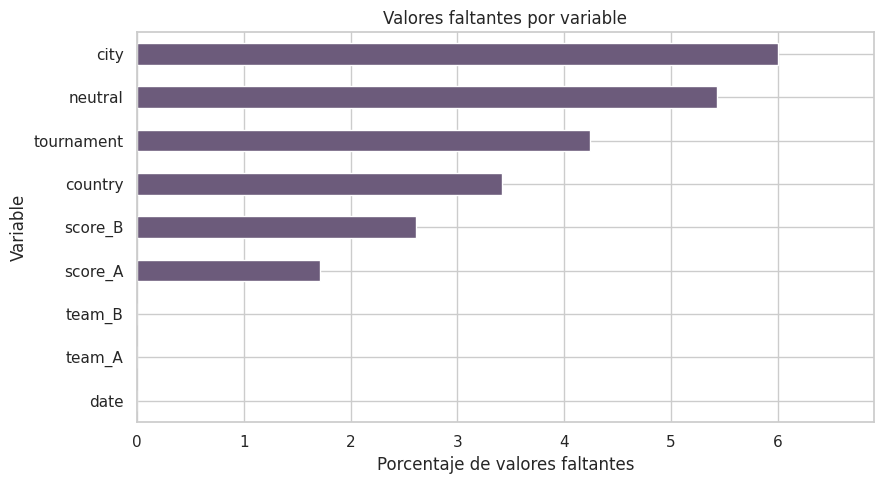

In [5]:
print("Tipos de datos:")
display(df.dtypes.to_frame("tipo")) # mostramos el tipo de dato de cada columna en una tabla

quality = pd.DataFrame({  # Crea un DataFrame para resumir la calidad de los datos de cada columna
    "nulos": df.isna().sum(),  # contamos cuántos valores faltantes o NaN hay en cada columna
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique()  # contamos cuántos valores diferentes tiene cada columna, sin contar los valores faltantes
})
display(quality)  # mostramos la tabla con la cantidad de nulos, su porcentaje y los valores únicos
print("Duplicados exactos:", df.duplicated().sum())  # filas que están completamente repetidas

missing_percentage = quality["porcentaje_nulos"].sort_values() # seleccionamos los porcentajes de nulos y los ordenamos de menor a mayor

plt.figure(figsize=(9, 5))
missing_percentage.plot(kind="barh", color="#6C5B7B")
plt.title("Valores faltantes por variable")
plt.xlabel("Porcentaje de valores faltantes")
plt.ylabel("Variable")
plt.xlim(0, max(1, missing_percentage.max() * 1.15))
plt.tight_layout()
plt.show()


<a id="sec-5-1"></a>
## 5.1. Decisiones de limpieza





### 5.1.1. Normalización de datos

*   **Convertimos cada columna al tipo de dato correspondiente**: la fecha se transforma a formato fecha, los goles a valores numéricos enteros y la variable neutral a booleana. Los valores que no pueden convertirse correctamente pasan a considerarse faltantes.
*   **Eliminamos los espacios innecesarios** al principio y al final de los nombres de las selecciones, los torneos, las ciudades y los países. Esto evita que un mismo valor sea interpretado como dos categorías diferentes.



In [6]:
df["date"] = pd.to_datetime(df["date"], errors="coerce") # convertimos la fecha al formato fecha y los valores faltantes se convierten en NaT

text_columns = ["team_A", "team_B", "tournament", "city", "country"] # normalizamos las columnas de texto.

for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
    )

# Convertimos los goles a números enteros
for column in ["score_A", "score_B"]:
    scores = pd.to_numeric(df[column], errors="coerce")
    scores = scores.where(scores % 1 == 0)
    df[column] = scores.astype("Int64")

# Definimos las formas posibles de representar True y False
neutral_values = {
    "true": True,
    "false": False,
    "1": True,
    "0": False,
    "sí": True,
    "si": True,
    "no": False
}

# Normalizamos la columna neutral y la convertimos a booleana
df["neutral"] = (
    df["neutral"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(neutral_values)
    .astype("boolean")
)

# Mostramos los tipos de datos y los faltantes después de normalizar
display(pd.DataFrame({
    "tipo_de_dato": df.dtypes.astype(str),
    "valores_faltantes": df.isna().sum()
}))



,tipo_de_dato,valores_faltantes
date,datetime64[ns],0
team_A,string,0
team_B,string,0
score_A,Int64,846
score_B,Int64,1291
tournament,string,2101
city,string,2971
country,string,1695
neutral,boolean,2690


### 5.1.2. Depuración

*   **Eliminamos los duplicados exactos** ya que un mismo partido podría estar registrado más de una vez y adquirir un peso mayor que los demás.
*   **Descartamos los registros sin fecha** porque necesitamos ordenar los partidos cronológicamente.
*   **Descartamos los registros sin alguna de las selecciones**, porque no podríamos calcular correctamente su rendimiento histórico.
*   **Descartamos los registros sin goles** ya que los goles son necesarios para determinar el resultado del partido. También eliminamos los marcadores negativos.
*   **Eliminamos los partidos en los que ambas selecciones son iguales** porque no representan un enfrentamiento válido.
*   **Completamos los valores faltantes de la variable neutral con su valor más frecuente**, para conservar los partidos que contienen el resto de la información necesaria.










In [7]:
required = ["date", "team_A", "team_B", "score_A", "score_B"] # definimos las columnas indispensables para poder utilizar un partido

rows_before_cleaning = len(df) # guardamos la cantidad de filas existentes antes de comenzar la depuración

duplicates_removed = df.duplicated().sum() # contamos cuántas filas están completamente duplicadas
df = df.drop_duplicates().copy() # eliminamos las filas completamente repetidas

missing_required = df[required].isna().any(axis=1) # identificamos los registros que tienen datos faltantes en alguna columna indispensable
missing_required_removed = missing_required.sum() # contamos cuántos registros tienen fecha, equipos o goles faltantes
df = df.dropna(subset=required).copy() # eliminamos los registros que no tienen todos los datos indispensables

negative_scores = (df["score_A"] < 0) | (df["score_B"] < 0) # identificamos los partidos que tienen algún marcador negativo
negative_scores_removed = negative_scores.sum() # contamos cuántos partidos tienen marcadores negativos
df = df[~negative_scores].copy() # eliminamos los partidos que tienen algún marcador negativo

same_teams = df["team_A"] == df["team_B"] # identificamos los partidos en los que ambas selecciones son iguales
same_teams_removed = same_teams.sum() # contamos cuántos partidos tienen la misma selección en ambos lados
df = df[~same_teams].copy() # eliminamos los partidos en los que ambas selecciones son iguales

neutral_missing = df["neutral"].isna().sum() # contamos cuántos valores faltantes tiene la variable neutral
neutral_mode = df["neutral"].mode(dropna=True) # calculamos el valor más frecuente de la variable neutral
neutral_fill_value = neutral_mode.iloc[0] if not neutral_mode.empty else False # usamos el valor más frecuente o False si toda la columna estuviera vacía
df["neutral"] = df["neutral"].fillna(neutral_fill_value) # completamos los valores faltantes de neutral con el valor seleccionado

df = df.sort_values("date") # ordenamos los partidos cronológicamente según su fecha

df = df.reset_index(drop=True) # reiniciamos la numeración de las filas después de eliminar registros

total_removed = rows_before_cleaning - len(df) # calculamos la cantidad total de registros eliminados

# Ahora creamos un resumen de los cambios realizados durante la depuración
cleaning_summary = pd.Series({
    "filas_iniciales": rows_before_cleaning,
    "duplicados_eliminados": duplicates_removed,
    "registros_incompletos_eliminados": missing_required_removed,
    "marcadores_negativos_eliminados": negative_scores_removed,
    "equipos_iguales_eliminados": same_teams_removed,
    "valores_neutral_completados": neutral_missing,
    "filas_totales_eliminadas": total_removed,
    "filas_finales": len(df)
}, name="cantidad")

display(cleaning_summary.to_frame())

# Creamos los controles para ver que la depuración haya funcionado
validation = pd.Series({
    "fechas_nulas": df["date"].isna().sum(),
    "equipos_nulos": df[["team_A", "team_B"]].isna().sum().sum(),
    "goles_nulos": df[["score_A", "score_B"]].isna().sum().sum(),
    "neutral_nulos": df["neutral"].isna().sum(),
    "marcadores_negativos": (
        (df["score_A"] < 0) | (df["score_B"] < 0)
    ).sum(),
    "equipos_iguales": (df["team_A"] == df["team_B"]).sum(),
    "duplicados_finales": df.duplicated().sum()
}, name="cantidad")

display(validation.to_frame()) # mostramos las validaciones finales, que deberían dar 0.

,cantidad
filas_iniciales,49520
duplicados_eliminados,0
registros_incompletos_eliminados,2121
marcadores_negativos_eliminados,0
equipos_iguales_eliminados,0
valores_neutral_completados,2585
filas_totales_eliminadas,2121
filas_finales,47399


,cantidad
fechas_nulas,0
equipos_nulos,0
goles_nulos,0
neutral_nulos,0
marcadores_negativos,0
equipos_iguales,0
duplicados_finales,0


## 5.2. Preparación de los datos para el modelado

*   **Utilizamos partidos disputados desde 1990** porque corresponden a una etapa más comparable con el fútbol actual.
*   **Creamos una variable de ventaja de sede**, que toma el valor 1 cuando la sede corresponde a la Selección A, -1 cuando corresponde a la Selección B y 0 cuando el encuentro se disputa en una sede neutral.
*   **El historial finaliza el 31 de julio de 2026** ya que las predicciones se realizan para partidos disputados desde agosto de 2026. Así evitamos que los resultados que queremos predecir formen parte del entrenamiento.





In [8]:
HISTORICAL_START = pd.Timestamp("1990-01-01")  # define el comienzo del período histórico
HISTORICAL_END = pd.Timestamp("2026-07-31")  # define la última fecha permitida para entrenar
PREDICTION_START = pd.Timestamp("2026-08-01")  # define el inicio del período de predicción

rows_before_period_filter = len(df)

df = df[
    (df["date"] >= HISTORICAL_START)  # conserva los partidos disputados desde 1990
    & (df["date"] <= HISTORICAL_END)  # conserva los partidos disputados hasta julio de 2026
].copy()

rows_removed_by_period = rows_before_period_filter - len(df)  # calcula cuántas filas quedaron fuera del período

df = df.sort_values("date").reset_index(drop=True)

df["venue_advantage_A"] = np.where(
    df["neutral"],  # comprueba si el encuentro se disputó en una sede neutral
    0,  # asigna 0 cuando el partido fue neutral
    1   # asigna 1 cuando A tuvo la condición de local
)

df["year"] = df["date"].dt.year  # extrae el año de cada partido
df["decade"] = (df["year"] // 10) * 10  # agrupa los partidos por década

df["total_goals"] = df["score_A"] + df["score_B"]  # calcula el total de goles del partido
df["goal_difference_A_B"] = df["score_A"] - df["score_B"]  # calcula la diferencia de goles desde la perspectiva de A

df["target"] = np.select(
    [
        df["score_A"] > df["score_B"],  # comprueba si ganó la Selección A
        df["score_A"] == df["score_B"]  # comprueba si el partido terminó empatado
    ],
    [
        "Victoria Selección A",
        "Empate"
    ],
    default="Victoria Selección B"
)

preparation_summary = pd.Series({
    "inicio_periodo": df["date"].min().date(),
    "fin_periodo": df["date"].max().date(),
    "filas_fuera_del_periodo": rows_removed_by_period,
    "partidos_preparados": len(df)
}, name="resultado")

display(preparation_summary.to_frame())
display(df.head())

,resultado
inicio_periodo,1990-01-12
fin_periodo,2026-07-19
filas_fuera_del_periodo,16414
partidos_preparados,30985


,date,team_A,team_B,score_A,score_B,tournament,city,country,neutral,venue_advantage_A,year,decade,total_goals,goal_difference_A_B,target
0,1990-01-12,Algeria,Mali,5,0,Friendly,Paris,France,True,0,1990,1990,5,5,Victoria Selección A
1,1990-01-14,Algeria,Cameroon,3,1,<NA>,Paris,France,True,0,1990,1990,4,2,Victoria Selección A
2,1990-01-17,Mexico,Argentina,2,0,Friendly,Los Angeles,United States,True,0,1990,1990,2,2,Victoria Selección A
3,1990-01-17,Greece,Belgium,2,0,Friendly,Athens,<NA>,False,1,1990,1990,2,2,Victoria Selección A
4,1990-01-20,Malawi,Tanzania,2,2,Friendly,Lobamba,Swaziland,True,0,1990,1990,4,0,Empate


<a id="sec-6"></a>
# 6. ***Análisis exploratorio de datos (EDA)***

Hacemos 2 gráficos:

1.  **Distribución de resultados**: con este gráfico se busca conocer cuántos partidos terminaron en victoria de la Selección A, empate o victoria de la Selección B. Esto permite identificar si las categorías se encuentran equilibradas o si algún resultado aparece con mayor frecuencia que los demás.
2.   **Partidos internacionales por año**: con este gráfico se busca observar cómo se distribuyen los partidos a lo largo del tiempo. Permite detectar años con muchos o pocos registros, posibles períodos sin información y comprobar si el dataset contiene una cantidad suficiente de partidos recientes. Como el dataset incluye todo tipo de partidos internacionales y no solamente los mundiales, se espera encontrar información en prácticamente todos los años.

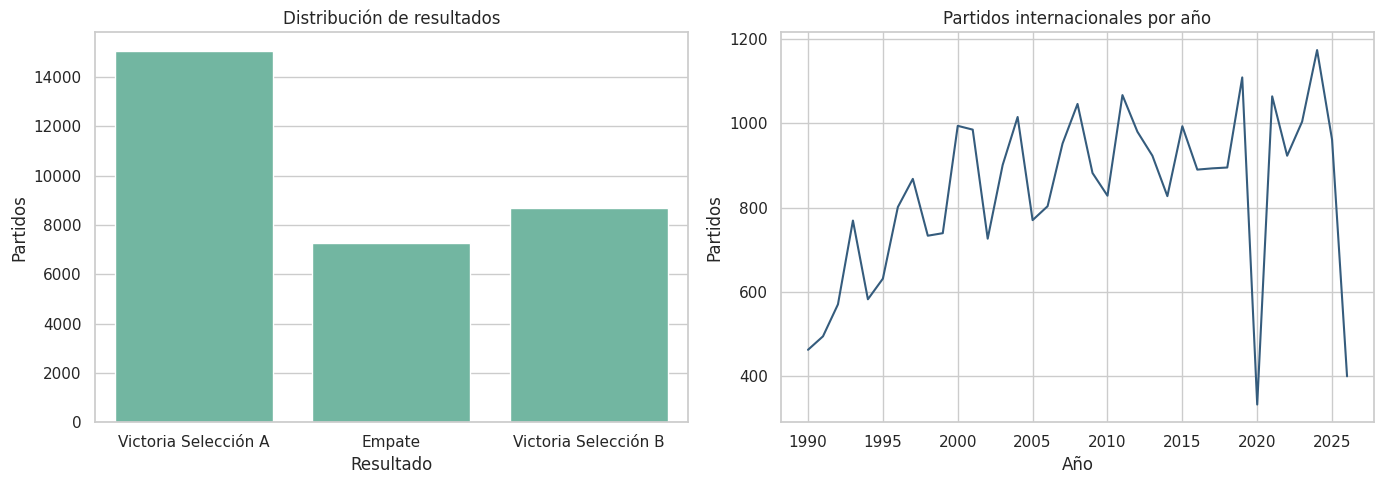

,porcentaje
target,
Victoria Selección A,48.59
Victoria Selección B,27.97
Empate,23.43


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["Victoria Selección A", "Empate", "Victoria Selección B"]
sns.countplot(data=df, x="target", order=order, ax=axes[0]) # cuenta cuántos partidos hay de cada resultado y dibuja las barras en el primer gráfico
axes[0].set(title="Distribución de resultados", xlabel="Resultado", ylabel="Partidos")

yearly = df.set_index("date").resample("YE").size()  # usa la fecha como índice, agrupa los partidos por año y cuenta cuántos se disputaron en cada uno
axes[1].plot(yearly.index.year, yearly.values, color="#355C7D")
axes[1].set(title="Partidos internacionales por año", xlabel="Año", ylabel="Partidos")
plt.tight_layout()
plt.show()

display((df["target"].value_counts(normalize=True) * 100).round(2).rename("porcentaje"))  # calcula qué porcentaje representa cada resultado, lo redondea a 2 decimales y lo muestra en una tabla

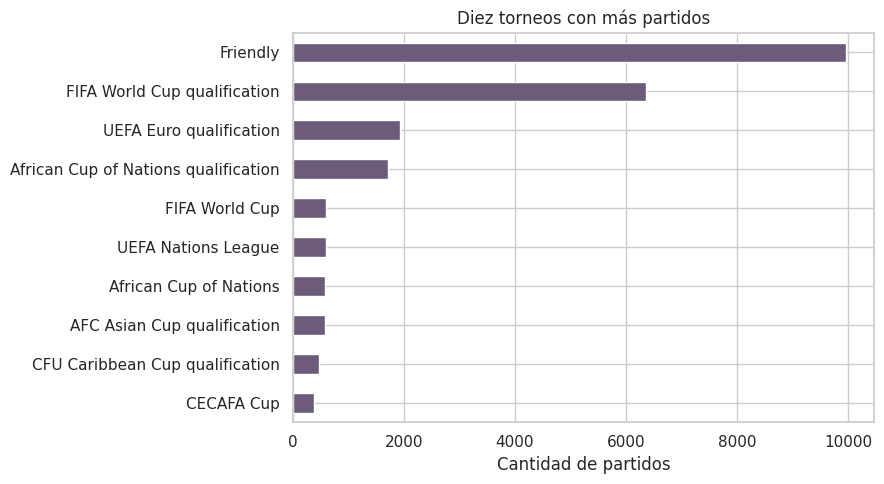

In [10]:
top_tournaments = df["tournament"].value_counts().head(10).sort_values()  # contamos los partidos de cada torneo, seleccionamos los 10 con más encuentros y los ordenamos de menor a mayor
plt.figure(figsize=(9, 5))
top_tournaments.plot(kind="barh", color="#6C5B7B")
plt.title("Diez torneos con más partidos")
plt.xlabel("Cantidad de partidos")
plt.ylabel("")
plt.tight_layout()
plt.show()

<a id="sec-6-1"></a>
## 6.1. EDA univariado

En esta etapa analizamos cada variable por separado para entender mejor cómo se comportan los datos. Utilizamos estadísticos descriptivos, como el promedio, la mediana, el mínimo y el máximo para obtener un resumen general.

También usamos histogramas para observar qué valores aparecen con mayor frecuencia y boxplots para detectar posibles valores extremos. En nuestro caso, un partido con una cantidad de goles muy elevada puede parecer atípico, pero no necesariamente es un error ya que puede tratarse de un resultado real. Por eso, estos valores se revisan, pero no se eliminan automáticamente

,count,mean,std,min,25%,50%,75%,max,median,iqr
score_A,30985.0,1.66,1.71,0.0,0.0,1.0,2.0,31.0,1.0,2.0
score_B,30985.0,1.11,1.35,0.0,0.0,1.0,2.0,21.0,1.0,2.0
total_goals,30985.0,2.76,1.99,0.0,1.0,2.0,4.0,31.0,2.0,3.0
goal_difference_A_B,30985.0,0.55,2.36,-21.0,-1.0,0.0,2.0,31.0,0.0,3.0


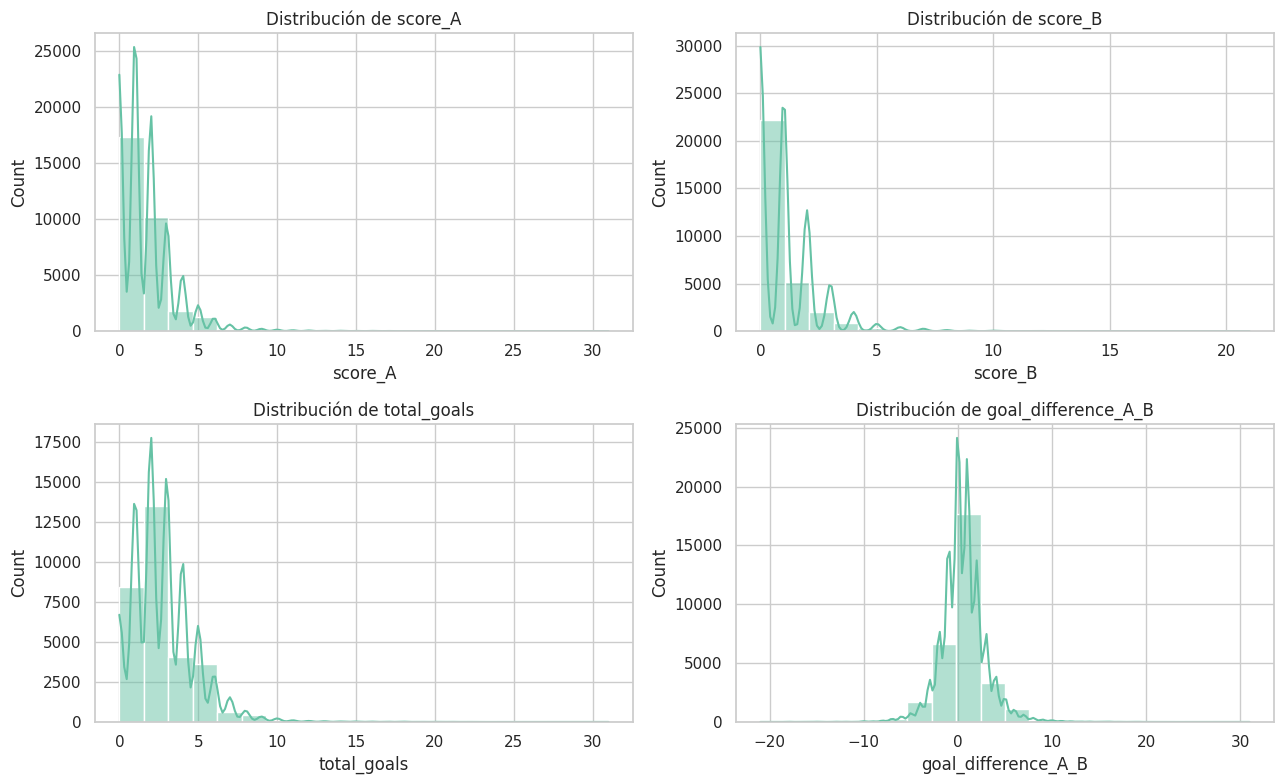

In [11]:
numeric_summary = df[["score_A", "score_B", "total_goals", "goal_difference_A_B"]].describe().T  # calcula estadísticas descriptivas de las 4 variables y coloca cada variable en una fila

numeric_summary["median"] = df[["score_A", "score_B", "total_goals", "goal_difference_A_B"]].median()  # calcula la mediana de cada variable y la agrega como una nueva columna de la tabla
numeric_summary["iqr"] = numeric_summary["75%"] - numeric_summary["25%"]  # calcula el rango intercuartílico restando el primer cuartil al tercer cuartil
display(numeric_summary.round(2))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
numeric_eda = ["score_A", "score_B", "total_goals", "goal_difference_A_B"]
for variable, axis in zip(numeric_eda, axes.flatten()):  # relaciona cada variable con uno de los 4 espacios disponibles y los recorre simultáneamente
    sns.histplot(df[variable], bins=20, kde=True, ax=axis)
    axis.set_title(f"Distribución de {variable}")
plt.tight_layout()
plt.show()

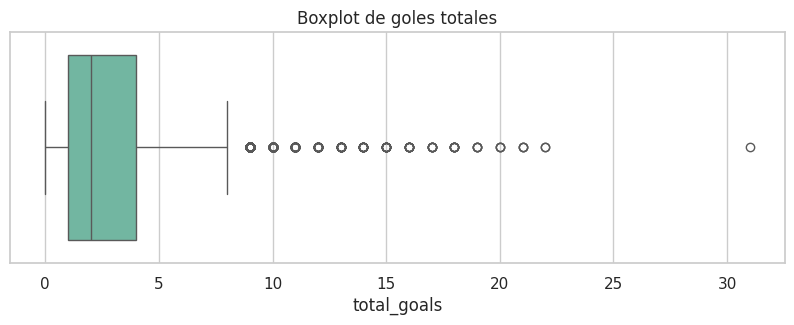

Partidos señalados como extremos por IQR: 372


,date,team_A,team_B,score_A,score_B,total_goals
7950,2001-04-11,Australia,American Samoa,31,0,31
7947,2001-04-09,Australia,Tonga,22,0,22
19046,2013-06-24,Provence,Tibet,22,0,22
4636,1997-05-13,Kazakhstan,Guam,20,1,21
11383,2005-03-11,Guam,North Korea,0,21,21


In [12]:
q1 = df["total_goals"].quantile(0.25)  # calcula el primer cuartil: el 25% de los partidos tiene esta cantidad de goles o menos
q3 = df["total_goals"].quantile(0.75)  # calcula el tercer cuartil: el 75% de los partidos tiene esta cantidad de goles o menos
iqr = q3 - q1  # calcula el rango intercuartílico, que mide la amplitud del 50% central de los datos
upper_limit = q3 + 1.5 * iqr  # calcula el límite a partir del cual una cantidad de goles se considera estadísticamente extrema
possible_outliers = df[df["total_goals"] > upper_limit]  # selecciona los partidos cuyos goles totales superan el límite calculado

plt.figure(figsize=(10, 3))
sns.boxplot(data=df, x="total_goals")
plt.title("Boxplot de goles totales")
plt.show()
print("Partidos señalados como extremos por IQR:", len(possible_outliers))
display(possible_outliers.nlargest(5, "total_goals")[[  # seleccionamos y muestra los 5 partidos con mayor cantidad total de goles.
    "date", "team_A", "team_B", "score_A", "score_B", "total_goals"
]])

En conclusión, la mayoría de los partidos presenta una cantidad baja o moderada de goles, con una mediana de 2 goles por encuentro. Aunque se identificaron 372 resultados extremos, estos no se eliminaron, ya que pueden corresponder a partidos reales y no necesariamente a errores en los datos.

<a id="sec-6-2"></a>
## 6.2. EDA bivariado

Ahora se analizan dos variables al mismo tiempo. Primero observamos si los resultados cambian cuando el partido se juega en cancha neutral. Después comparamos la cantidad de goles según el resultado del encuentro y, por último, analizamos la relación entre las variables numéricas. Esto nos va a permitir identificar qué datos podrían ser útiles para entrenar los modelos

target,Empate,Victoria Selección A,Victoria Selección B
neutral,,,
False,23.44,50.65,25.91
True,23.43,43.00,33.58


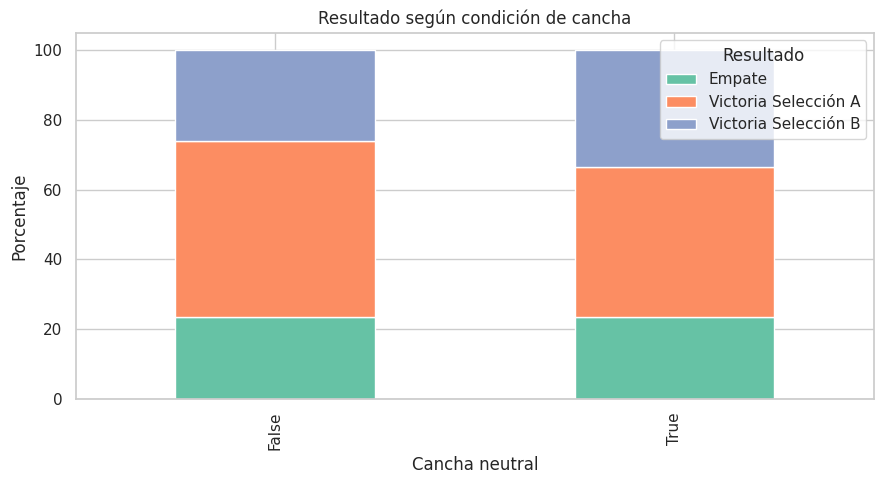

In [13]:
neutral_result = pd.crosstab(  # creamos una tabla que relaciona la condición de cancha con el resultado del partido
    df["neutral"], df["target"], normalize="index" # calculamos qué proporción representa cada resultado dentro de los partidos neutrales y no neutrales
).mul(100).round(2)  # convertimos las proporciones en porcentajes y redondea los resultados a 2 decimales
display(neutral_result)

neutral_result.plot(kind="bar", stacked=True, figsize=(9, 5))  # hacemos un gráfico de barras para comparar los resultados según la condición de cancha
plt.title("Resultado según condición de cancha")
plt.xlabel("Cancha neutral")
plt.ylabel("Porcentaje")
plt.legend(title="Resultado")
plt.tight_layout()
plt.show()

En conclusión, la condición de cancha sí influye en el resultado. Cuando el partido no se juega en una sede neutral, la Selección A, que representa al equipo local, gana el 50,65% de los encuentros. En cancha neutral, sus victorias disminuyen al 43%, mientras que las de la Selección B aumentan. En cambio, el porcentaje de empates se mantiene prácticamente igual. Esto nos muestra la existencia de una ventaja asociada a jugar como local.

A continuación generamos 2 gráficos, con los cuales buscamos:

*   Goles totales según resultado: busca saber si la cantidad de goles suele ser diferente cuando gana la Selección A, empatan o gana la Selección B.
*   Evolución de los resultados por década: busca observar si la frecuencia de cada resultado cambió con el paso del tiempo. Por ejemplo, permite identificar si actualmente hay más o menos empates que en décadas anteriores.



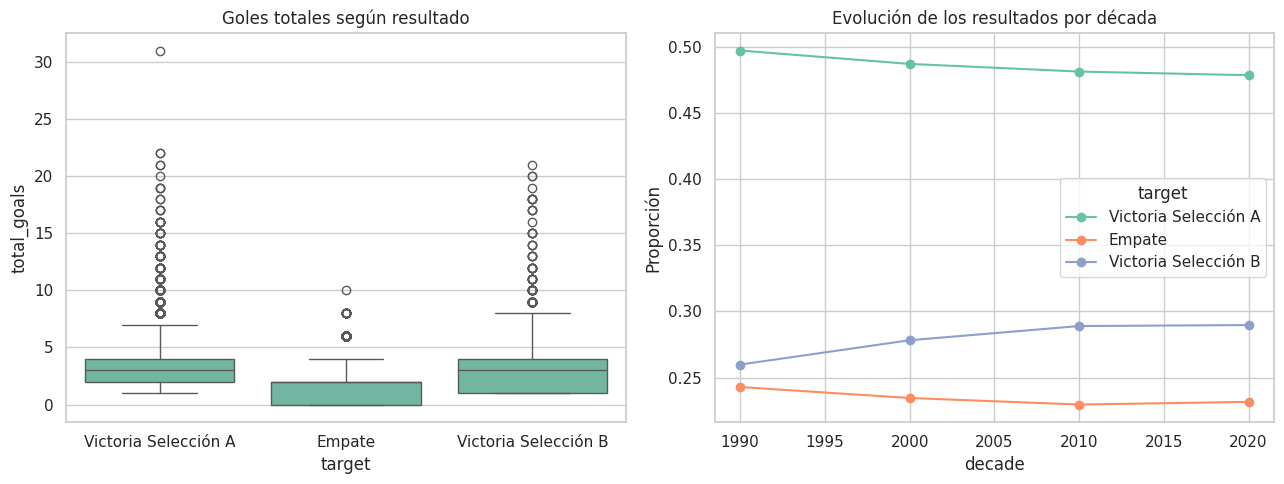

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="target", y="total_goals", order=order, ax=axes[0])
axes[0].set_title("Goles totales según resultado")

decade_result = pd.crosstab(df["decade"], df["target"], normalize="index")
decade_result[order].plot(ax=axes[1], marker="o")
axes[1].set_title("Evolución de los resultados por década")
axes[1].set_ylabel("Proporción")
plt.tight_layout()
plt.show()

En conclusión, los empates suelen presentar una menor cantidad total de goles que los partidos que tienen ganador, mientras que las victorias de ambas selecciones muestran distribuciones similares y algún que otro resultado extremo.

A lo largo de las décadas, las proporciones se mantienen relativamente estables, aunque las victorias de la Selección A disminuyen levemente y las de la Selección B aumentan. Aun así, la Selección A continúa siendo la categoría más frecuente, lo que puede estar relacionado con la ventaja de jugar como local.

<a id="sec-6-3"></a>
## 6.3. Matriz de correlación

Con la matriz de correlación buscamos analizar si existe una relación entre las variables numéricas del dataset. Esto nos va a permitir observar si 2 variables tienden a aumentar juntas, si una disminuye cuando la otra aumenta o si no presentan relación. También ayuda a identificar variables que contienen información similar. En este caso, analizamos la relación entre los goles de ambas selecciones, los goles totales, la diferencia de goles y el año del partido.

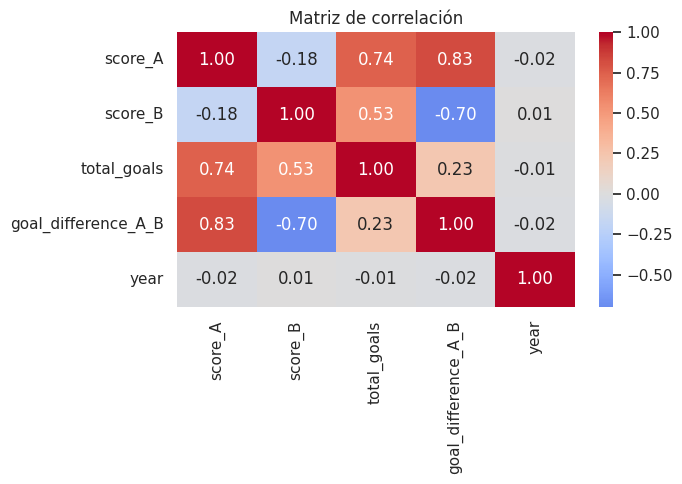

In [15]:
correlation_columns = ["score_A", "score_B", "total_goals", "goal_difference_A_B", "year"]
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

Al analizar la matriz, observamos que los goles de las dos selecciones se relacionan de manera positiva con los goles totales. Esto es esperable porque, cuando cualquiera de las dos marca más goles, aumenta el total del partido.

La relación entre los goles de la Selección A y la diferencia de goles A-B es positiva. En cambio, la relación de los goles de la Selección B con esa diferencia es negativa, ya que cada gol de B reduce la diferencia a favor de A.

Finalmente, el año presenta valores cercanos a cero con el resto de las variables. Esto indica que no existe una relación lineal clara entre el paso del tiempo y la cantidad o diferencia de goles.

<a id="sec-7"></a>
# 7. Ingeniería de variables

Antes de cada partido, construimos nuevas variables utilizando solamente información de encuentros anteriores. Estas variables permiten comparar el rendimiento de las dos selecciones:

* **Puntaje Elo**: indica la fortaleza de cada selección. El puntaje aumenta cuando una selección gana y disminuye cuando pierde. Ganarle a una selección fuerte genera un aumento mayor que ganarle a una débil.
* **Forma reciente**: muestra cómo viene jugando cada selección. Se consideran sus últimos cinco partidos y se asignan 3 puntos por victoria, 1 por empate y 0 por derrota.
* **Goles recientes a favor y en contra**: se calcula el promedio de goles marcados y recibidos por cada selección en sus últimos cinco partidos.
* **Partidos previos**: indica cuántos encuentros había disputado cada selección hasta ese momento.
* **Días de descanso**: compara cuántos días pasaron desde el último partido de cada selección.
* **Enfrentamientos directos**: resume los puntos obtenidos por la Selección A en los últimos partidos contra la Selección B.
* **Diferencias A-B**: se comparan el Elo, la forma reciente, los goles y la experiencia de la Selección A con los de la Selección B.
* **Información del partido**: se incorpora el torneo, el año, el mes, la condición neutral y `venue_advantage_A`. Esta última vale 1 si se juega en el país de A, -1 si se juega en el país de B y 0 si la sede es neutral.

El procesamiento se realiza siguiendo el orden de las fechas. Primero se calculan las variables con la información disponible antes del partido y recién después se incorpora el resultado al historial. Así logramos que el modelo no utilice información futura.

In [16]:
from collections import defaultdict, deque


def build_pre_match_features(matches, window=5, k_factor=20):
    elo = defaultdict(lambda: 1500.0) # guarda el Elo, y las selecciones nuevas comienzan con 1500 puntos
    points = defaultdict(lambda: deque(maxlen=window)) # guarda los puntos de los últimos 5 partidos
    goals_for = defaultdict(lambda: deque(maxlen=window)) # guarda los goles marcados en los últimos 5 partidos
    goals_against = defaultdict(lambda: deque(maxlen=window)) # guarda los goles recibidos en los últimos 5 partidos
    games = defaultdict(int) # guarda la cantidad de partidos previos de cada selección
    last_date = {} # guarda la fecha del último partido de cada selección
    h2h = defaultdict(lambda: deque(maxlen=5)) # guarda los últimos 5 enfrentamientos entre cada pareja
    rows = [] # guarda las nuevas variables creadas para cada partido

    def avg(history, default=1.0): # calcula el promedio de un historial
        return float(np.mean(history)) if len(history) else default # si no hay datos anteriores, devuelve 1

    def opposite_points(value): # convierte los puntos de una selección en los puntos de su rival
        return {3: 0, 1: 1, 0: 3}[value] # victoria pasa a derrota, empate sigue igual y derrota pasa a victoria

    for match in matches.itertuples(index=False):
        team_a = match.team_A
        team_b = match.team_B
        elo_a = elo[team_a] # obtenemos el Elo de A antes del partido
        elo_b = elo[team_b] # obtenemos el Elo de B antes del partido

        pair = tuple(sorted((team_a, team_b)))
        prior_h2h = [ # recupera los puntos de los enfrentamientos anteriores desde la perspectiva de A
            value if team_a == pair[0] else opposite_points(value)
            for value in h2h[pair] # recorre los enfrentamientos previos entre ambas selecciones
        ]

        rest_a = ( # calcula los días de descanso de A
            (match.date - last_date[team_a]).days
            if team_a in last_date else 30 # si A no tiene partidos previos, le asigna 30 días
        )
        rest_b = ( # calcula los días de descanso de B
            (match.date - last_date[team_b]).days
            if team_b in last_date else 30 # si B no tiene partidos previos, le asigna 30 días
        )

        rows.append({
            "date": match.date,
            "team_A": team_a,
            "team_B": team_b,
            "tournament": match.tournament,
            "neutral": bool(match.neutral),
            "venue_advantage_A": int(match.venue_advantage_A),
            "year": match.date.year,
            "month": match.date.month,
            "elo_A": elo_a,
            "elo_B": elo_b,
            "elo_diff_A_B": elo_a - elo_b,
            "form_A": avg(points[team_a]),
            "form_B": avg(points[team_b]),
            "form_diff_A_B": avg(points[team_a]) - avg(points[team_b]),
            "goals_for_A": avg(goals_for[team_a]),
            "goals_for_B": avg(goals_for[team_b]),
            "goals_against_A": avg(goals_against[team_a]),
            "goals_against_B": avg(goals_against[team_b]),
            "games_diff_A_B": games[team_a] - games[team_b],
            "rest_diff_A_B": (
                np.clip(rest_a, 0, 60) - np.clip(rest_b, 0, 60) # limitamos el descanso a 60 días para evitar valores excesivos
            ),
            "h2h_A_points": avg(prior_h2h),
            "target": match.target
        })

        if match.score_A > match.score_B: # comprueba si ganó la Selección A
            points_a, points_b, actual_a = 3, 0, 1.0 # A recibe 3 puntos, B recibe 0 y A obtiene valor Elo 1
        elif match.score_A == match.score_B: # comprueba si el partido terminó empatado
            points_a, points_b, actual_a = 1, 1, 0.5 # ambas reciben 1 punto y A obtiene valor Elo 0,5
        else:  # se ejecuta cuando ganó la Selección B
            points_a, points_b, actual_a = 0, 3, 0.0

        expected_a = 1 / (1 + 10 ** ((elo_b - elo_a) / 400)) # calcula el resultado esperado de A según los puntajes Elo
        elo_change = k_factor * (actual_a - expected_a) # calcula cuánto debe modificarse el Elo después del partido
        elo[team_a] += elo_change
        elo[team_b] -= elo_change

        points[team_a].append(points_a) # agrega los puntos obtenidos al historial reciente de A
        points[team_b].append(points_b) # agrega los puntos obtenidos al historial reciente de B
        goals_for[team_a].append(match.score_A) # agrega los goles marcados al historial de A
        goals_against[team_a].append(match.score_B) # agrega los goles recibidos al historial de A
        goals_for[team_b].append(match.score_B) # agrega los goles marcados al historial de B
        goals_against[team_b].append(match.score_A) # agrega los goles recibidos al historial de B

        # El historial guarda los puntos desde la perspectiva de la primera
        # selección de la pareja ordenada alfabéticamente.
        h2h[pair].append( # guarda el resultado en el historial de enfrentamientos directos
            points_a if team_a == pair[0] else points_b # lo guarda desde la perspectiva de la primera selección alfabética
        )

        last_date[team_a] = match.date # actualiza la fecha del último partido de A
        last_date[team_b] = match.date # actualiza la fecha del último partido de B
        games[team_a] += 1 # Suma un partido disputado al historial de A
        games[team_b] += 1 # Suma un partido disputado al historial de B

    state = { # guarda el estado histórico final de todas las selecciones
        "elo": dict(elo),
        "points": {team: list(values) for team, values in points.items()},
        "goals_for": {
            team: list(values) for team, values in goals_for.items()
        },
        "goals_against": {
            team: list(values) for team, values in goals_against.items()
        },
        "games": dict(games),
        "last_date": dict(last_date),
        "h2h": {pair: list(values) for pair, values in h2h.items()}
    }
    return pd.DataFrame(rows), state


features, historical_state = build_pre_match_features(df)
display(features.head(5))
print("Dataset modelable:", features.shape)

,date,team_A,team_B,tournament,neutral,venue_advantage_A,year,month,elo_A,elo_B,elo_diff_A_B,form_A,form_B,form_diff_A_B,goals_for_A,goals_for_B,goals_against_A,goals_against_B,games_diff_A_B,rest_diff_A_B,h2h_A_points,target
0,1990-01-12,Algeria,Mali,Friendly,True,0,1990,1,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0,0,1.0,Victoria Selección A
1,1990-01-14,Algeria,Cameroon,<NA>,True,0,1990,1,1510.0,1500.0,10.0,3.0,1.0,2.0,5.0,1.0,0.0,1.0,1,-28,1.0,Victoria Selección A
2,1990-01-17,Mexico,Argentina,Friendly,True,0,1990,1,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0,0,1.0,Victoria Selección A
3,1990-01-17,Greece,Belgium,Friendly,False,1,1990,1,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0,0,1.0,Victoria Selección A
4,1990-01-20,Malawi,Tanzania,Friendly,True,0,1990,1,1500.0,1500.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0,0,1.0,Empate


Dataset modelable: (30985, 22)


<a id="sec-8"></a>
# 8. Separación temporal de entrenamiento y prueba

En este caso no dividimos los datos de manera aleatoria, porque podrían mezclarse partidos antiguos con partidos más recientes. Utilizamos el 80% de los primeros partidos para entrenar los modelos y el 20% más reciente para evaluar su funcionamiento. De esta manera, los modelos aprenden a partir de información pasada y luego intentan predecir resultados futuros.

Entrenamiento: 24,788 partidos (1990-01-12 a 2019-10-10)
Prueba: 6,197 partidos (2019-10-10 a 2026-07-19)


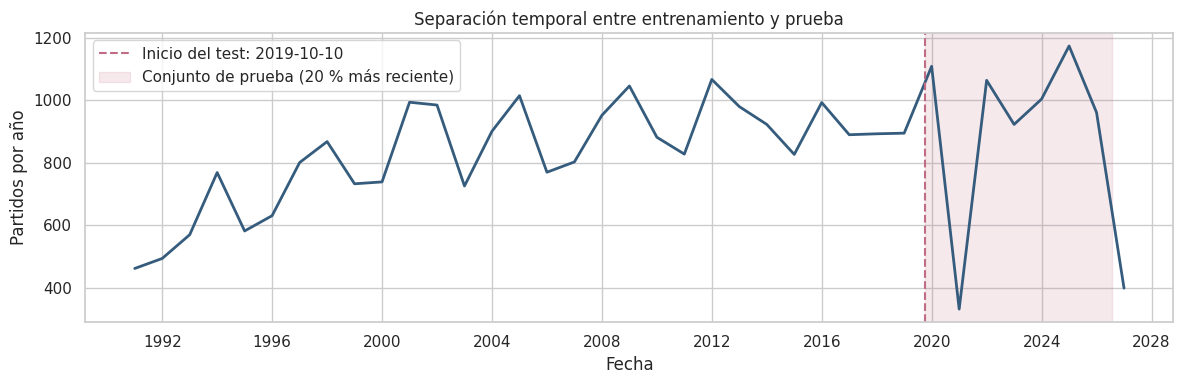

In [17]:
feature_cols = [  # creamos una lista con los nombres de las variables que los modelos utilizarán para realizar las predicciones
    "tournament", "neutral", "venue_advantage_A", "year", "month",  # incorporamos el torneo, la sede, el año y el mes del partido
    "elo_A", "elo_B", "elo_diff_A_B",  # incorporamos el Elo de ambas selecciones y la diferencia A-B
    "form_A", "form_B", "form_diff_A_B",  # incorporamos la forma reciente de ambas selecciones y la diferencia A-B
    "goals_for_A", "goals_for_B", "goals_against_A", "goals_against_B",  # incorporamos los promedios recientes de goles a favor y en contra
    "games_diff_A_B", "rest_diff_A_B", "h2h_A_points"  # incorporamos experiencia, descanso y enfrentamientos directos desde la perspectiva de A
]
X = features[feature_cols]  # creamos X con todas las variables que los modelos utilizarán para predecir el resultado
y = features["target"]  # creamos "y" con el resultado real que los modelos deberán aprender a predecir

cut = int(len(features) * 0.80) # calcula la posición que representa el 80% de los partidos y la convierte en un número entero
X_train, X_test = X.iloc[:cut], X.iloc[cut:]  # coloca en entrenamiento el 80% inicial de las variables y en prueba el 20% más reciente
y_train, y_test = y.iloc[:cut], y.iloc[cut:]  # divide los resultados reales utilizando el mismo punto de separación

print(f"Entrenamiento: {len(X_train):,} partidos ({features.date.iloc[0].date()} a {features.date.iloc[cut-1].date()})")  # Muestra la cantidad y el período de los partidos utilizados para entrenar los modelos
print(f"Prueba: {len(X_test):,} partidos ({features.date.iloc[cut].date()} a {features.date.iloc[-1].date()})")  # Muestra la cantidad y el período de los partidos utilizados para evaluar los modelos

# Ahora mostramos visualmente dónde termina el entrenamiento y dónde comienza la prueba
matches_per_year = features.set_index("date").resample("YE").size()
test_start = features["date"].iloc[cut]

plt.figure(figsize=(12, 4))
plt.plot(
    matches_per_year.index,
    matches_per_year.values,
    color="#355C7D",
    linewidth=2
)
plt.axvline(
    test_start,
    color="#C06C84",
    linestyle="--",
    label=f"Inicio del test: {test_start.date()}"
)
plt.axvspan(
    test_start,
    features["date"].max(),
    color="#C06C84",
    alpha=0.15,
    label="Conjunto de prueba (20 % más reciente)"
)
plt.title("Separación temporal entre entrenamiento y prueba")
plt.xlabel("Fecha")
plt.ylabel("Partidos por año")
plt.legend()
plt.tight_layout()
plt.show()

<a id="sec-9"></a>
# 9. ***Análisis bivariado y ANOVA***

Utilizamos ANOVA para comprobar si las variables numéricas presentan valores promedio diferentes según el resultado del partido. Un p-valor menor a 0,05 indica que existen diferencias significativas entre al menos dos de los tres resultados y que la variable podría aportar información útil.

,variable,F,p_value,significativa_5%
0,elo_diff_A_B,2924.969476,0.000000,True
1,elo_B,995.920335,0.000000,True
2,games_diff_A_B,1110.376233,0.000000,True
3,form_diff_A_B,996.047696,0.000000,True
4,h2h_A_points,1133.981947,0.000000,True
5,elo_A,673.897402,0.000000,True
6,goals_against_A,534.565039,0.000000,True
7,form_B,491.984054,0.000000,True
8,goals_against_B,489.351946,0.000000,True
9,form_A,411.180831,0.000000,True


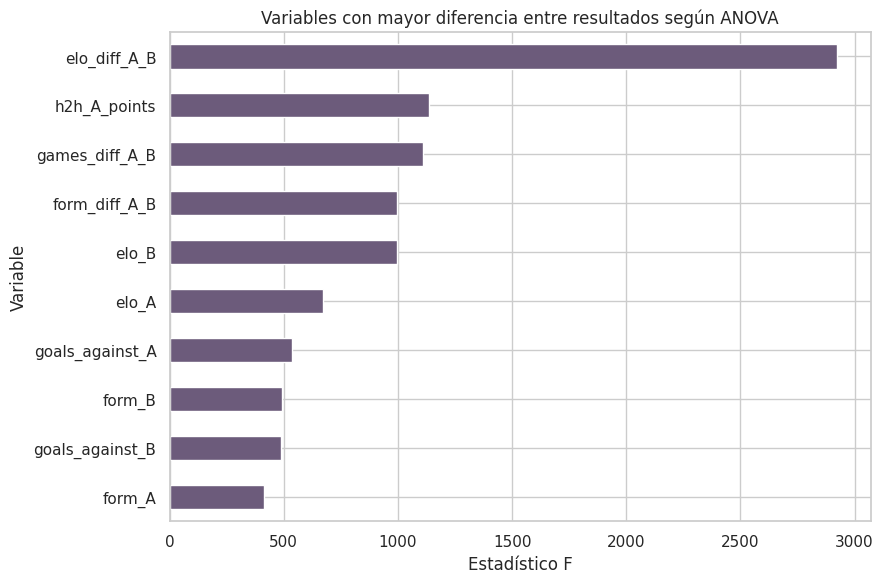

In [18]:
numeric_for_anova = X_train.select_dtypes(include=np.number).columns  # seleccionamos los nombres de las variables numéricas del conjunto de entrenamiento
anova_rows = []  # creamos una lista  donde se irán guardando los resultados de ANOVA para cada variable

for variable in numeric_for_anova:  # recorremos una por una todas las variables numéricas seleccionadas
    clean = X_train[variable].fillna(X_train[variable].median())  # reemplazamos los valores faltantes de la variable por su mediana para poder realizar ANOVA
    f_value, p_value = f_classif(clean.to_frame(), y_train)  # comparamos los valores de la variable entre los tres resultados y calcula el estadístico F y el p-valor
    anova_rows.append({  # agregamos a la lista los resultados obtenidos para la variable analizada
        "variable": variable,
        "F": f_value[0],  # guardamos el valor F, que indica qué tan diferentes son los promedios de los tres grupos
        "p_value": p_value[0],  # guardamos el p-valor utilizado para determinar si la diferencia encontrada es significativa
        "significativa_5%": p_value[0] < 0.05  # devuelve True si el p-valor es menor a 0,05 y False si es mayor o igual
    })

anova_results = (pd.DataFrame(anova_rows)
                 .sort_values("p_value")  # ordena las variables desde el p-valor más pequeño hasta el más grande.
                 .reset_index(drop=True))
display(anova_results.round(6))

# Compara de manera visual las diez variables con mayor estadístico F.
anova_plot = (
    anova_results.nlargest(10, "F")
    .sort_values("F")
    .set_index("variable")["F"]
)

plt.figure(figsize=(9, 6))
anova_plot.plot(kind="barh", color="#6C5B7B")
plt.title("Variables con mayor diferencia entre resultados según ANOVA")
plt.xlabel("Estadístico F")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


Los resultados de ANOVA muestran que la mayoría de las variables numéricas presentan diferencias significativas entre los tres resultados posibles. La diferencia de Elo es una de las variables con mayor relación con el resultado, seguida por los enfrentamientos directos, la experiencia y la forma reciente. En cambio, el mes no presenta una diferencia significativa porque su p-valor es mayor a 0,05. Esto no garantiza que una variable permita predecir correctamente por sí sola, pero indica cuáles podrían aportar información a los modelos.

<a id="sec-10"></a>
# 10. ***Preprocesamiento***

Antes de entrenar los modelos, preparamos las variables para que puedan ser utilizadas.

Si una variable numérica tiene un valor faltante, lo reemplazamos por la mediana de esa variable. Después, colocamos las variables numéricas en una escala similar para evitar que las que poseen valores más grandes tengan una influencia que sea excesiva.

En las variables categóricas, como el torneo o la condición de cancha, los valores faltantes se reemplazan por la categoría más frecuente. Luego utilizamos one-hot encoding para convertir las categorías en números. Por ejemplo, cada torneo se transforma en una columna diferente con valores 1 o 0.


In [19]:
categorical = ["tournament", "neutral"]
numeric = [
    column for column in feature_cols
    if column not in categorical
]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric),
    ("cat", categorical_pipe, categorical)
], sparse_threshold=1.0)

In [20]:
def preparar_faltantes_sklearn(X):
    X = X.copy()

    for column in X.columns:
        if pd.api.types.is_numeric_dtype(X[column]):
            X[column] = pd.to_numeric(
                X[column], errors="coerce"
            ).astype("float64")
        else:
            X[column] = X[column].astype(object)
            X.loc[X[column].isna(), column] = np.nan

    return X


X_train = preparar_faltantes_sklearn(X_train)
X_test = preparar_faltantes_sklearn(X_test)

<a id="sec-11"></a>
# 11. ***Modelos candidatos***

In [21]:
labels = ["Victoria Selección A", "Empate", "Victoria Selección B"]


def evaluate(name, fitted_model, X_eval, y_eval):  # definimos una función para evaluar cualquier modelo entrenado

    pred = fitted_model.predict(X_eval)  # predice el resultado de cada partido

    prob = fitted_model.predict_proba(X_eval)  # calculamos la probabilidad de cada resultado posible

    return {

        "modelo": name,

        "accuracy": accuracy_score(
            y_eval, pred
        ),  # calcula la proporción total de predicciones correctas

        "precision_macro": precision_score(
            y_eval, pred, average="macro", zero_division=0
        ),  # calcula la precisión promedio dando igual importancia a las tres categorías

        "recall_macro": recall_score(
            y_eval, pred, average="macro", zero_division=0
        ),  # calcula qué proporción de cada resultado real detectó el modelo

        "f1_macro": f1_score(
            y_eval, pred, average="macro", zero_division=0
        ),  # combina precision y recall para comparar equilibradamente las categorías

        "roc_auc_macro": roc_auc_score(
            y_eval,
            prob,
            labels=fitted_model.classes_,
            multi_class="ovr",
            average="macro"
        )  # evalúa qué tan bien diferencia cada resultado frente a los demás

    }, pred  # devuelve las métricas y las predicciones individuales


model_results = []  # guardamos las métricas obtenidas por los seis modelos


logistic = Pipeline([  # creamos el Pipeline de Regresión Logística

    ("prep", preprocessor),  # prepara las variables antes de entrenar.

    ("model", LogisticRegression(
        max_iter=2000,  # permite suficientes iteraciones para encontrar una solución estable.
        class_weight="balanced",  # compensa las diferencias entre las categorías.
        random_state=SEED  # permite reproducir los resultados.
    ))
])


knn = Pipeline([  # creamos el Pipeline de KNN

    ("prep", preprocessor),  # prepara las variables antes de entrenar

    ("model", KNeighborsClassifier(
        n_neighbors=15,  # considera los 15 partidos más parecidos
        weights="distance"  # da mayor importancia a los partidos más cercanos
    ))
])

tree = Pipeline([  # creamos el Pipeline del Árbol de Decisión

    ("prep", preprocessor),  # prepara las variables antes de entrenar.

    ("model", DecisionTreeClassifier(
        max_depth=10,  # limita el árbol a 10 niveles para reducir el sobreajuste
        class_weight="balanced",  # compensa las diferencias entre las categorías.
        random_state=SEED
    ))
])

forest = Pipeline([  # creamos el Pipeline de Random Forest.

    ("prep", preprocessor),  # prepara las variables antes de entrenar.

    ("model", RandomForestClassifier(
        n_estimators=300,  # construye 300 árboles de decisión
        class_weight="balanced",  # compensa el desbalance entre las categorías.
        n_jobs=-1,  # utiliza todos los núcleos disponibles
        random_state=SEED  # permite reproducir los resultados
    ))
])


adaboost = Pipeline([  # creamos el Pipeline de AdaBoost.

    ("prep", preprocessor),  # prepara las variables antes de entrenar

    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=SEED
        ),
        n_estimators=200,  # Combina 200 clasificadores débiles
        learning_rate=0.05,  # Controla el aporte de cada clasificador
        random_state=SEED  # Permite reproducir los resultados
    ))
])


xgboost = Pipeline([  # creamos el Pipeline de XGBoost

    ("prep", preprocessor),  # prepara las variables antes de entrenar

    ("model", XGBClassifier(
        objective="multi:softprob",  # predice probabilidades para varias categorías.
        num_class=3,  # indica que existen tres resultados posibles.
        n_estimators=300,  # construye 300 árboles de forma secuencial.
        learning_rate=0.05,  # Controla cuánto aporta cada nuevo árbol.
        max_depth=5,  # limita la profundidad de cada árbol.
        eval_metric="mlogloss",  # evalúa el error de clasificación multiclase.
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1  # Utiliza todos los núcleos disponibles.
    ))
])


label_encoder = LabelEncoder()  # crea el codificador necesario para XGBoost

y_train_xgb = label_encoder.fit_transform(
    y_train
)  # convierte las categorías de entrenamiento en 0, 1 y 2

y_test_xgb = label_encoder.transform(
    y_test
)  # aplica la misma conversión a las categorías de prueba

candidate_models = [  # Agrupa los seis modelos y las variables objetivo que utilizarán.

    ("Regresión Logística", logistic, y_train, y_test),

    ("KNN", knn, y_train, y_test),

    ("Árbol de Decisión", tree, y_train, y_test),

    ("Random Forest", forest, y_train, y_test),

    ("AdaBoost (ensamble)", adaboost, y_train, y_test),

    ("XGBoost", xgboost, y_train_xgb, y_test_xgb)
]


for name, model, y_fit, y_eval in candidate_models:  # recorre los 6 modelos.

    model.fit(
        X_train, y_fit
    )  # entrena cada modelo con su variable objetivo correspondiente.

    row, _ = evaluate(
        name, model, X_test, y_eval
    )  # evalúa el modelo utilizando el conjunto de prueba.

    model_results.append(row)  # guarda las métricas obtenidas.


display(
    pd.DataFrame(model_results)
    .set_index("modelo")
    .round(4)
)  # mostramos la tabla comparativa de los seis modelos

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
modelo,,,,,
Regresión Logística,0.5641,0.5214,0.5278,0.5227,0.7354
KNN,0.5777,0.5048,0.4989,0.4870,0.7019
Árbol de Decisión,0.5144,0.4797,0.4860,0.4775,0.6716
Random Forest,0.6017,0.5318,0.5037,0.4641,0.7274
AdaBoost (ensamble),0.6000,0.3961,0.4944,0.4363,0.7246
XGBoost,0.6037,0.5026,0.5077,0.4632,0.7336


<a id="sec-12"></a>
# 12. ***Optimización con Grid Search y validación temporal***

Se utiliza Grid Search, uno de los métodos vistos en el curso, junto con TimeSeriesSplit. Grid Search prueba distintas combinaciones de hiperparámetros y va a conservar la de mejor F1. Con la validación vamos a respetar el orden de los partidos, o sea, se enntrena con el pasado y se valida con los períodos posteriores.

In [22]:
tscv = TimeSeriesSplit(n_splits=4) # creamos 4 divisiones cronológicas para validar sin mezclar pasado y futuro


log_grid = { # definimos los parámetros que se van a probar en regresión logística
    "model__C": [0.1, 1, 10], # prueba distintos niveles de regularización
    "model__solver": ["lbfgs", "saga"] # prueba dos algoritmos de optimización
}

knn_grid = { # define los parámetros que se probarán en KNN
    "model__n_neighbors": [7, 15], # prueba utilizar 7 o 15 partidos vecinos
    "model__weights": ["uniform", "distance"], # prueba dar el mismo peso o más peso a los vecinos cercanos
    "model__p": [2] # utilizamos la distancia euclidiana para medir la cercanía
}

tree_grid = { # definimos los parámetros que se probarán en el árbol de decisión
    "model__criterion": ["gini", "entropy"], # prueba 2 métodos para elegir las divisiones del árbol
    "model__max_depth": [6, 10], # limita el árbol a 6 o 10 niveles
    "model__min_samples_leaf": [2, 8] # exige al menos 2 u 8 observaciones en cada hoja
}

rf_grid = { # definimos los parámetros que se probarán en random forest
    "model__n_estimators": [200], # construye un conjunto de 200 árboles
    "model__max_depth": [10, 20], # prueba árboles con una profundidad máxima de 10 o 20 niveles
    "model__min_samples_leaf": [1, 4], # exige al menos 1 o 4 observaciones en cada hoja
    "model__max_features": ["sqrt"] # cada árbol considera la raíz cuadrada del total de variables
}

ada_grid = { # definimos los parámetros que se probarán en AdaBoost
    "model__n_estimators": [100, 200], # prueba combinar 100 o 200 árboles débiles
    "model__learning_rate": [0.05, 0.1], # prueba distintos niveles de aporte de cada árbol
    "model__estimator__max_depth": [1] # limita cada árbol individual a un solo nivel
}

xgb_grid = { # definimos los parámetros que se probarán en XGBoost
    "model__n_estimators": [250], # construye 250 árboles de manera secuencial
    "model__max_depth": [3, 6], # prueba árboles con una profundidad máxima de 3 o 6 niveles
    "model__learning_rate": [0.03, 0.1],  # prueba distintas velocidades de aprendizaje
    "model__subsample": [0.8], # cada árbol utiliza el 80 % de las observaciones de entrenamiento
    "model__colsample_bytree": [0.8] # cada árbol utiliza el 80 % de las variables disponibles
}

searches = {}
tuning_configs = [ # agrupa cada modelo, su grilla y la variable objetivo correspondiente
    ("Regresión Logística optimizada", logistic, log_grid, y_train),
    ("KNN optimizado", knn, knn_grid, y_train),
    ("Árbol optimizado", tree, tree_grid, y_train),
    ("Random Forest optimizado", forest, rf_grid, y_train),
    ("AdaBoost (ensamble) optimizado", adaboost, ada_grid, y_train),
    ("XGBoost optimizado", xgboost, xgb_grid, y_train_xgb)
]

for name, model, params, y_fit in tuning_configs: # recorre los seis modelos para optimizarlos
    search = GridSearchCV( # prueba todas las combinaciones de parámetros de cada grilla
        estimator=model, # indica el modelo que se va a optimizar
        param_grid=params, # indica las combinaciones de parámetros que se van a probar.
        scoring="f1_macro", # elige la mejor combinación según el F1-macro
        cv=tscv, # valida respetando el orden cronológico de los partidos
        n_jobs=-1, # utiliza todos los núcleos disponibles para acelerar la búsqueda
        refit=True  # vuelve a entrenar el modelo con la mejor combinación encontrada
    )
    search.fit(X_train, y_fit)
    searches[name] = search

    print(
        name,
        "| Mejor CV F1-macro:",
        round(search.best_score_, 4)
    )
    print("Mejores parámetros:", search.best_params_, "\n")

Regresión Logística optimizada | Mejor CV F1-macro: 0.4954
Mejores parámetros: {'model__C': 0.1, 'model__solver': 'lbfgs'} 

KNN optimizado | Mejor CV F1-macro: 0.4545
Mejores parámetros: {'model__n_neighbors': 15, 'model__p': 2, 'model__weights': 'uniform'} 

Árbol optimizado | Mejor CV F1-macro: 0.4869
Mejores parámetros: {'model__criterion': 'gini', 'model__max_depth': 6, 'model__min_samples_leaf': 8} 

Random Forest optimizado | Mejor CV F1-macro: 0.4873
Mejores parámetros: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 200} 

AdaBoost (ensamble) optimizado | Mejor CV F1-macro: 0.4098
Mejores parámetros: {'model__estimator__max_depth': 1, 'model__learning_rate': 0.1, 'model__n_estimators': 200} 

XGBoost optimizado | Mejor CV F1-macro: 0.4525
Mejores parámetros: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 250, 'model__subsample': 0.8} 



<a id="sec-13"></a>
# 13. ***Evaluación final y selección del modelo***

,modelo,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
0,Regresión Logística optimizada,0.5683,0.5227,0.5308,0.5246,0.7356
1,Regresión Logística,0.5641,0.5214,0.5278,0.5227,0.7354
2,Árbol optimizado,0.5664,0.5121,0.5205,0.5150,0.7191
3,Random Forest optimizado,0.5779,0.5056,0.5215,0.5075,0.7277
4,KNN optimizado,0.5709,0.5025,0.4948,0.4889,0.7009
5,KNN,0.5777,0.5048,0.4989,0.4870,0.7019
6,Árbol de Decisión,0.5144,0.4797,0.4860,0.4775,0.6716
7,XGBoost optimizado,0.5925,0.5017,0.5045,0.4770,0.7278
8,Random Forest,0.6017,0.5318,0.5037,0.4641,0.7274
9,XGBoost,0.6037,0.5026,0.5077,0.4632,0.7336


Modelo seleccionado por validación temporal: Regresión Logística optimizada


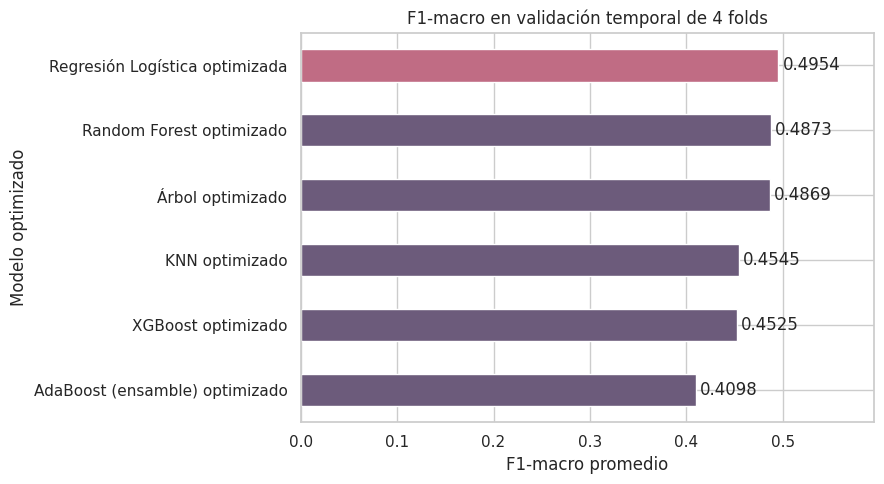

In [23]:
tuned_results = []  # Guarda las métricas de los seis modelos optimizados.
predictions = {}  # Guarda sus predicciones.

optimized_models = {
    name: search.best_estimator_
    for name, search in searches.items()
}

cv_scores = {
    name: search.best_score_
    for name, search in searches.items()
}

for name, fitted_model in optimized_models.items():
    y_eval = (
        y_test_xgb if name == "XGBoost optimizado" else y_test
    )

    row, pred = evaluate(
        name,
        fitted_model,
        X_test,
        y_eval
    )
    tuned_results.append(row)

    if name == "XGBoost optimizado":
        pred = label_encoder.inverse_transform(pred)

    predictions[name] = pred


comparison = (
    pd.DataFrame(model_results + tuned_results)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)

display(comparison.round(4))


best_name = max(
    cv_scores,
    key=cv_scores.get
)
best_model = optimized_models[best_name]

print("Modelo seleccionado por validación temporal:", best_name)


# Compara el F1-macro utilizado para elegir el modelo
cv_plot = pd.Series(
    cv_scores,
    name="F1-macro"
).sort_values()

bar_colors = [
    "#C06C84" if model_name == best_name else "#6C5B7B"
    for model_name in cv_plot.index
]

ax = cv_plot.plot(
    kind="barh",
    figsize=(9, 5),
    color=bar_colors
)
ax.bar_label(ax.containers[0], fmt="%.4f", padding=3)
plt.title(f"F1-macro en validación temporal de {tscv.n_splits} folds")
plt.xlabel("F1-macro promedio")
plt.ylabel("Modelo optimizado")
plt.xlim(0, min(1, cv_plot.max() * 1.20))
plt.tight_layout()
plt.show()


<a id="sec-13-1"></a>
## 13.1. Comparación de modelos

Se comparan seis modelos: Regresión Logística, KNN, Árbol de Decisión, Random Forest, AdaBoost y XGBoost. Para cada uno se evalúan tanto la versión inicial como la optimizada mediante Grid Search con validación temporal.

| Modelo              | Aporte al análisis                                                | Principal limitación                                  |
| ------------------- | ----------------------------------------------------------------- | ----------------------------------------------------- |
| Regresión Logística | Es simple, rápida e interpretable                                 | Puede no captar relaciones no lineales                |
| KNN                 | Clasifica según partidos históricos similares                     | Es sensible a la escala y puede ser lento al predecir |
| Árbol de Decisión   | Genera reglas fáciles de interpretar                              | Puede sobreajustarse a los datos de entrenamiento     |
| Random Forest       | Capta interacciones y relaciones no lineales                      | Es menos fácil de interpretar                         |
| AdaBoost (ensamble) | Entrena árboles débiles de forma secuencial y prioriza los errores | Puede ser sensible al ruido y a valores extremos      |
| XGBoost             | Modela relaciones complejas y corrige progresivamente los errores | Requiere mayor ajuste y tiempo de procesamiento       |

Se prioriza el F1-score macro porque combina precisión y recall y evalúa de forma equilibrada los tres resultados posibles, sin favorecer a la categoría más frecuente. Las demás métricas se utilizan como complemento.


,modelo,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro,ranking_f1_macro
0,Regresión Logística optimizada,0.5683,0.5227,0.5308,0.5246,0.7356,1
1,Regresión Logística,0.5641,0.5214,0.5278,0.5227,0.7354,2
2,Árbol optimizado,0.5664,0.5121,0.5205,0.5150,0.7191,3
3,Random Forest optimizado,0.5779,0.5056,0.5215,0.5075,0.7277,4
4,KNN optimizado,0.5709,0.5025,0.4948,0.4889,0.7009,5
5,KNN,0.5777,0.5048,0.4989,0.4870,0.7019,6
6,Árbol de Decisión,0.5144,0.4797,0.4860,0.4775,0.6716,7
7,XGBoost optimizado,0.5925,0.5017,0.5045,0.4770,0.7278,8
8,Random Forest,0.6017,0.5318,0.5037,0.4641,0.7274,9
9,XGBoost,0.6037,0.5026,0.5077,0.4632,0.7336,10


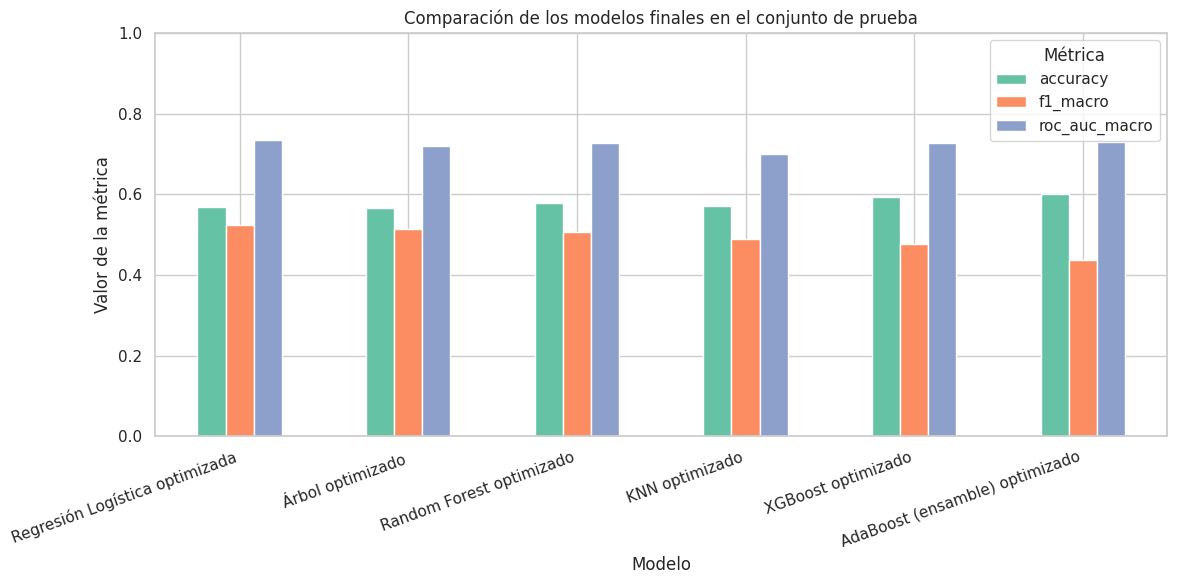

In [24]:
metricas = [
    "accuracy", "precision_macro", "recall_macro",
    "f1_macro", "roc_auc_macro"
]

comparison_view = comparison[
    ["modelo"] + metricas
].copy()  # Crea una tabla con los modelos y sus cinco métricas.

comparison_view["ranking_f1_macro"] = (
    comparison_view["f1_macro"]
    .rank(ascending=False, method="min")
    .astype(int)
)  # Asigna el puesto 1 al mayor F1-macro del conjunto de prueba.

comparison_view = comparison_view.sort_values(
    "ranking_f1_macro"
)  # Ordena los modelos desde el mayor hasta el menor F1-macro.

display(comparison_view.round(4))  # Muestra la tabla comparativa.


final_models_view = comparison_view[
    comparison_view["modelo"].isin(optimized_models)
].copy()

plot_metrics = final_models_view.set_index("modelo")[[
    "accuracy", "f1_macro", "roc_auc_macro"
]]

plot_metrics.plot(
    kind="bar",
    figsize=(12, 6)
)  # Resume las tres métricas principales de los modelos optimizados.

plt.title("Comparación de los modelos finales en el conjunto de prueba")
plt.ylabel("Valor de la métrica")
plt.xlabel("Modelo")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

<a id="sec-13-2"></a>
## 13.2. Criterio y justificación de la elección

La métrica principal es el F1-macro porque combina precision y recall y evalúa de forma equilibrada la predicción de las tres clases, sin favorecer al resultado más frecuente. El ROC-AUC macro y la accuracy se utilizan como métricas complementarias.

Los seis modelos se optimizan y comparan mediante Grid Search con validación temporal. La selección se realiza según el mayor F1-macro obtenido durante esa validación, utilizando únicamente los datos de entrenamiento. El conjunto de prueba contiene partidos posteriores y se utiliza solamente para evaluar el rendimiento final, evitando que influya en la elección.

El nombre del modelo seleccionado y su F1-macro se muestran automáticamente en la celda siguiente. De esta manera, la conclusión siempre coincide con los resultados obtenidos al volver a ejecutar el notebook.

In [25]:
selected_row = comparison_view.loc[
    comparison_view["modelo"] == best_name
].iloc[0]  # Obtiene los resultados finales del modelo seleccionado.

print(f"Modelo seleccionado: {best_name}")
print(f"F1-macro en validación temporal: {cv_scores[best_name]:.4f}")

print("\nRendimiento final en el conjunto de prueba:")
print(f"Accuracy: {selected_row['accuracy']:.4f}")
print(f"Precision macro: {selected_row['precision_macro']:.4f}")
print(f"Recall macro: {selected_row['recall_macro']:.4f}")
print(f"F1-score macro: {selected_row['f1_macro']:.4f}")
print(f"ROC-AUC macro: {selected_row['roc_auc_macro']:.4f}")

Modelo seleccionado: Regresión Logística optimizada
F1-macro en validación temporal: 0.4954

Rendimiento final en el conjunto de prueba:
Accuracy: 0.5683
Precision macro: 0.5227
Recall macro: 0.5308
F1-score macro: 0.5246
ROC-AUC macro: 0.7356


Accuracy del modelo Regresión Logística optimizada: 0.5683

Reporte de clasificación:
                      precision    recall  f1-score   support

Victoria Selección A       0.72      0.65      0.68      2975
              Empate       0.29      0.28      0.29      1421
Victoria Selección B       0.55      0.66      0.60      1801

            accuracy                           0.57      6197
           macro avg       0.52      0.53      0.52      6197
        weighted avg       0.57      0.57      0.57      6197



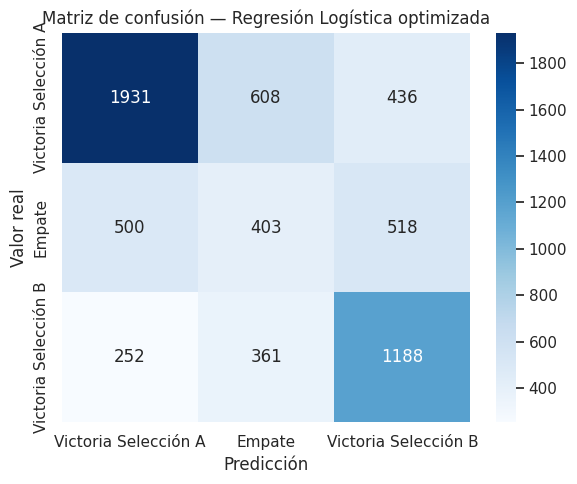

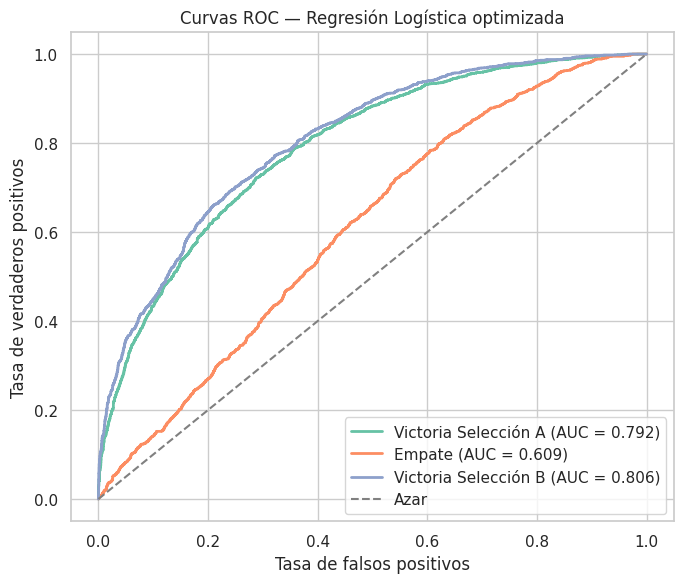


F1-macro promedio con validación temporal de 4 folds: 0.4954


In [26]:
best_pred = predictions[best_name]
n_folds = tscv.n_splits  # Obtiene automáticamente la cantidad de folds utilizados.

print(
    f"Accuracy del modelo {best_name}:",
    round(accuracy_score(y_test, best_pred), 4)
)

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        best_pred,
        labels=labels,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=labels
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title(f"Matriz de confusión — {best_name}")
plt.tight_layout()
plt.show()

# Curvas ROC multiclase del modelo seleccionado.
best_probabilities = best_model.predict_proba(X_test)
best_classes = np.asarray(best_model.classes_)

if np.issubdtype(best_classes.dtype, np.number):
    best_classes = label_encoder.inverse_transform(
        best_classes.astype(int)
    )

probability_by_class = pd.DataFrame(
    best_probabilities,
    columns=best_classes,
    index=X_test.index
).reindex(columns=labels)

y_test_binary = label_binarize(y_test, classes=labels)

plt.figure(figsize=(7, 6))

for class_position, class_name in enumerate(labels):
    fpr, tpr, _ = roc_curve(
        y_test_binary[:, class_position],
        probability_by_class[class_name]
    )
    class_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "--", color="gray", label="Azar")
plt.title(f"Curvas ROC — {best_name}")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"\nF1-macro promedio con validación temporal de {n_folds} folds:",
    round(cv_scores[best_name], 4)
)

<a id="sec-13-3"></a>
## 13.3. Interpretación

La matriz de confusión permite identificar en qué resultados acierta y se equivoca el modelo. El empate suele ser la clase más difícil de predecir y menos frecuente, por lo que no alcanza con observar únicamente la accuracy. También se analizaron precision, recall, F1-macro y ROC-AUC, priorizando el F1-macro porque evalúa de forma equilibrada las tres clases (gana, empata, pierde)

<a id="sec-14"></a>
# 14. ***Aplicación a próximos partidos internacionales***

La siguiente función aplica el modelo seleccionado a partidos entre selecciones que se disputen desde el 1 de agosto de 2026. La base histórica utilizada para entrenar queda fija hasta el 31 de julio de 2026, por lo que el resultado del encuentro que se quiere predecir no puede ingresar en el modelo.


In [32]:
# Entrenamos el modelo elegido con todo el historial disponible.
X_completo = preparar_faltantes_sklearn(X)
modelo_prediccion = clone(best_model)

y_completo = (
    label_encoder.transform(y)
    if best_name == "XGBoost optimizado" else y
)

modelo_prediccion.fit(X_completo, y_completo)


# Permite escribir las selecciones en español o en inglés.
import unicodedata


def clave_nombre(nombre):
    texto = unicodedata.normalize("NFD", str(nombre).strip().casefold())
    return "".join(letra for letra in texto if unicodedata.category(letra) != "Mn")


alias = {
    "afganistan": "Afghanistan",
    "alemania": "Germany",
    "antigua y barbuda": "Antigua and Barbuda",
    "arabia saudita": "Saudi Arabia",
    "argelia": "Algeria",
    "azerbaiyan": "Azerbaijan",
    "barein": "Bahrain",
    "belgica": "Belgium",
    "belice": "Belize",
    "benin": "Benin",
    "bielorrusia": "Belarus",
    "birmania": "Myanmar",
    "bosnia y herzegovina": "Bosnia and Herzegovina",
    "botsuana": "Botswana",
    "brasil": "Brazil",
    "brunei": "Brunei",
    "butan": "Bhutan",
    "cabo verde": "Cape Verde",
    "camboya": "Cambodia",
    "camerun": "Cameroon",
    "canada": "Canada",
    "catar": "Qatar",
    "chipre": "Cyprus",
    "comoras": "Comoros",
    "corea del norte": "North Korea",
    "corea del sur": "South Korea",
    "costa de marfil": "Ivory Coast",
    "croacia": "Croatia",
    "dinamarca": "Denmark",
    "egipto": "Egypt",
    "emiratos arabes unidos": "United Arab Emirates",
    "escocia": "Scotland",
    "eslovaquia": "Slovakia",
    "eslovenia": "Slovenia",
    "espana": "Spain",
    "estados unidos": "United States",
    "esuatini": "Eswatini",
    "etiopia": "Ethiopia",
    "filipinas": "Philippines",
    "finlandia": "Finland",
    "fiyi": "Fiji",
    "francia": "France",
    "gabon": "Gabon",
    "gales": "Wales",
    "granada": "Grenada",
    "grecia": "Greece",
    "guayana francesa": "French Guiana",
    "guinea bisau": "Guinea-Bissau",
    "guinea ecuatorial": "Equatorial Guinea",
    "haiti": "Haiti",
    "hungria": "Hungary",
    "inglaterra": "England",
    "irak": "Iraq",
    "iran": "Iran",
    "irlanda": "Republic of Ireland",
    "irlanda del norte": "Northern Ireland",
    "islandia": "Iceland",
    "islas caiman": "Cayman Islands",
    "islas cook": "Cook Islands",
    "islas feroe": "Faroe Islands",
    "islas salomon": "Solomon Islands",
    "islas virgenes britanicas": "British Virgin Islands",
    "islas virgenes estadounidenses": "United States Virgin Islands",
    "italia": "Italy",
    "japon": "Japan",
    "jordania": "Jordan",
    "kazajistan": "Kazakhstan",
    "kenia": "Kenya",
    "kirguistan": "Kyrgyzstan",
    "letonia": "Latvia",
    "libano": "Lebanon",
    "libia": "Libya",
    "lituania": "Lithuania",
    "luxemburgo": "Luxembourg",
    "macao": "Macau",
    "macedonia del norte": "North Macedonia",
    "malasia": "Malaysia",
    "malaui": "Malawi",
    "maldivas": "Maldives",
    "mali": "Mali",
    "marruecos": "Morocco",
    "mauricio": "Mauritius",
    "mexico": "Mexico",
    "moldavia": "Moldova",
    "noruega": "Norway",
    "nueva caledonia": "New Caledonia",
    "nueva zelanda": "New Zealand",
    "oman": "Oman",
    "paises bajos": "Netherlands",
    "panama": "Panama",
    "papua nueva guinea": "Papua New Guinea",
    "peru": "Peru",
    "polonia": "Poland",
    "republica centroafricana": "Central African Republic",
    "republica checa": "Czech Republic",
    "republica democratica del congo": "DR Congo",
    "republica dominicana": "Dominican Republic",
    "ruanda": "Rwanda",
    "rumania": "Romania",
    "rusia": "Russia",
    "samoa americana": "American Samoa",
    "san cristobal y nieves": "Saint Kitts and Nevis",
    "san vicente y las granadinas": "Saint Vincent and the Grenadines",
    "santa lucia": "Saint Lucia",
    "santo tome y principe": "São Tomé and Príncipe",
    "sierra leona": "Sierra Leone",
    "singapur": "Singapore",
    "siria": "Syria",
    "sudafrica": "South Africa",
    "sudan": "Sudan",
    "sudan del sur": "South Sudan",
    "suecia": "Sweden",
    "suiza": "Switzerland",
    "surinam": "Suriname",
    "tailandia": "Thailand",
    "taiwan": "Chinese Taipei",
    "tayikistan": "Tajikistan",
    "timor oriental": "Timor-Leste",
    "trinidad y tobago": "Trinidad and Tobago",
    "tunez": "Tunisia",
    "turkmenistan": "Turkmenistan",
    "turquia": "Turkey",
    "ucrania": "Ukraine",
    "uzbekistan": "Uzbekistan",
    "vietnam": "Vietnam",
    "yemen": "Yemen",
    "yibuti": "Djibouti",
    "zimbabue": "Zimbabwe"
}

equipos = set(df["team_A"]) | set(df["team_B"])
nombres_equipos = {clave_nombre(equipo): equipo for equipo in equipos}


def normalizar(nombre):
    nombre = str(nombre).strip()
    clave = clave_nombre(nombre)
    nombre_traducido = alias.get(clave, nombre)
    return nombres_equipos.get(clave_nombre(nombre_traducido), nombre_traducido)


def promedio(valores, default=1.0):
    return float(np.mean(valores)) if valores else default


def predecir_partido(seleccion_A, seleccion_B, sede):
    team_a = normalizar(seleccion_A)
    team_b = normalizar(seleccion_B)

    if team_a == team_b:
        raise ValueError("Las selecciones deben ser diferentes.")

    desconocidas = [
        equipo for equipo in (team_a, team_b)
        if equipo not in equipos
    ]
    if desconocidas:
        raise ValueError(
            "No se encontraron estas selecciones: "
            + ", ".join(desconocidas)
        )

    # En el historial, la Selección A representa al equipo local.
    sede_normalizada = normalizar(sede)
    if str(sede).strip().casefold() == "neutral":
        modelo_a, modelo_b, neutral = team_a, team_b, True
    elif sede_normalizada == team_a:
        modelo_a, modelo_b, neutral = team_a, team_b, False
    elif sede_normalizada == team_b:
        modelo_a, modelo_b, neutral = team_b, team_a, False
    else:
        modelo_a, modelo_b, neutral = team_a, team_b, True

    fecha = PREDICTION_START
    elo = historical_state["elo"]
    puntos = historical_state["points"]
    goles_favor = historical_state["goals_for"]
    goles_contra = historical_state["goals_against"]
    partidos = historical_state["games"]
    ultimas_fechas = historical_state["last_date"]

    par = tuple(sorted((modelo_a, modelo_b)))
    h2h = historical_state["h2h"].get(par, [])
    if modelo_a != par[0]:
        h2h = [{3: 0, 1: 1, 0: 3}[valor] for valor in h2h]

    descanso_a = (
        (fecha - ultimas_fechas[modelo_a]).days
        if modelo_a in ultimas_fechas else 30
    )
    descanso_b = (
        (fecha - ultimas_fechas[modelo_b]).days
        if modelo_b in ultimas_fechas else 30
    )

    nueva_fila = pd.DataFrame([{
        "tournament": "Friendly",
        "neutral": neutral,
        "venue_advantage_A": 0 if neutral else 1,
        "year": fecha.year,
        "month": fecha.month,
        "elo_A": elo.get(modelo_a, 1500),
        "elo_B": elo.get(modelo_b, 1500),
        "elo_diff_A_B": (
            elo.get(modelo_a, 1500) - elo.get(modelo_b, 1500)
        ),
        "form_A": promedio(puntos.get(modelo_a, [])),
        "form_B": promedio(puntos.get(modelo_b, [])),
        "form_diff_A_B": (
            promedio(puntos.get(modelo_a, []))
            - promedio(puntos.get(modelo_b, []))
        ),
        "goals_for_A": promedio(goles_favor.get(modelo_a, [])),
        "goals_for_B": promedio(goles_favor.get(modelo_b, [])),
        "goals_against_A": promedio(goles_contra.get(modelo_a, [])),
        "goals_against_B": promedio(goles_contra.get(modelo_b, [])),
        "games_diff_A_B": (
            partidos.get(modelo_a, 0) - partidos.get(modelo_b, 0)
        ),
        "rest_diff_A_B": (
            np.clip(descanso_a, 0, 60)
            - np.clip(descanso_b, 0, 60)
        ),
        "h2h_A_points": promedio(h2h)
    }])

    nueva_fila = nueva_fila[feature_cols]
    nueva_fila = preparar_faltantes_sklearn(nueva_fila)
    resultado_modelo = modelo_prediccion.predict(nueva_fila)[0]

    if best_name == "XGBoost optimizado":
        resultado_modelo = label_encoder.inverse_transform(
            [int(resultado_modelo)]
        )[0]

    nombres_originales = {
        team_a: str(seleccion_A).strip(),
        team_b: str(seleccion_B).strip()
    }

    if resultado_modelo == "Empate":
        resultado = "El partido termina en empate."
    elif resultado_modelo == "Victoria Selección A":
        resultado = (
            f"Gana {nombres_originales[modelo_a]} y "
            f"pierde {nombres_originales[modelo_b]}."
        )
    else:
        resultado = (
            f"Gana {nombres_originales[modelo_b]} y "
            f"pierde {nombres_originales[modelo_a]}."
        )

    print(f"Partido: {seleccion_A} vs. {seleccion_B}")
    print(f"Sede: {sede}")
    print(f"Predicción: {resultado}")

    return resultado


# Completá los tres datos cuando ejecutes la celda.
seleccion_A = input("Primera selección: ")
seleccion_B = input("Segunda selección: ")
sede = input("Sede (país o Neutral): ")

predecir_partido(seleccion_A, seleccion_B, sede)

Primera selección: Argentina
Segunda selección: Marruecos
Sede (país o Neutral): Argentina
Partido: Argentina vs. Marruecos
Sede: Argentina
Predicción: Gana Argentina y pierde Marruecos.


'Gana Argentina y pierde Marruecos.'

<a id="sec-15"></a>
# 15. ***Conclusiones generales***

A partir de este trabajo pudimos aplicar las principales etapas de un proyecto de Data Science a un caso real: cargamos y limpiamos los datos, analizamos sus características, construimos variables con información previa a cada partido, entrenamos distintos modelos y comparamos sus resultados. La separación temporal fue importante para evaluar los modelos con partidos posteriores a los utilizados durante el entrenamiento y evitar que aprendieran información del futuro.

El modelo seleccionado fue la Regresión Logística optimizada, ya que obtuvo el mejor F1-macro promedio en la validación temporal, con un valor de 0,4954. En el conjunto final de prueba alcanzó una accuracy de 0,5683 y un F1-macro de 0,5246. Estos resultados muestran que el modelo logra reconocer una parte importante de los resultados, aunque todavía comete errores y tiene una mayor dificultad para identificar los empates.

También observamos que los modelos más complejos no necesariamente obtuvieron un mejor desempeño. En este caso, la Regresión Logística logró un resultado más equilibrado que Random Forest, AdaBoost y XGBoost. Por lo tanto, concluimos que la predicción de partidos internacionales puede mejorarse mediante el análisis de información histórica, pero no puede considerarse exacta debido a la incertidumbre propia del fútbol. La aplicación final permite utilizar el modelo de una forma sencilla, ingresando dos selecciones y la sede del partido.

<a id="sec-16"></a>
# 16. ***Limitaciones***

El modelo utiliza resultados históricos y variables creadas a partir de partidos anteriores, pero no incorpora información que también puede influir en un encuentro, como los jugadores convocados, lesiones, cambios de entrenador, clima, importancia del partido o rendimiento individual. Además, el empate es la categoría menos frecuente y la más difícil de predecir, lo que reduce el desempeño equilibrado del modelo.

La base histórica queda actualizada hasta el 31 de julio de 2026. Por este motivo, las predicciones pueden perder precisión con el paso del tiempo si no se agregan nuevos partidos y se vuelve a entrenar el modelo. La aplicación final también supone que el encuentro es amistoso para no pedir datos adicionales al usuario. Por último, el modelo predice solamente victoria, empate o derrota: no estima el marcador exacto y sus resultados deben interpretarse como una aproximación, no como una certeza.

<a id="sec-17"></a>
# 17. ***Bibliografía***

- pandas. *Documentación oficial de pandas*. https://pandas.pydata.org/docs/
- scikit-learn. *Documentación oficial: selección de modelos, validación temporal y métricas*. https://scikit-learn.org/stable/
- Chen, T. y Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining. https://doi.org/10.1145/2939672.2939785
- seaborn. *Documentación oficial de visualización estadística*. https://seaborn.pydata.org/